En este notebook voy a realizar el modelo DBSCAN


In [36]:
from sklearn.cluster import DBSCAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [37]:
from google.colab import drive
drive.mount('/content/drive')

df =pd.read_excel("/content/drive/MyDrive/Aprendizaje no supervisado/Incidentes2014_2020.xlsx" )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
df.dropna(subset=['Latitud', 'Longitud'], inplace=True)

In [39]:
print(df.isnull().sum().sort_values(ascending=False))

Barrio                22939
CBML                  22067
Diseño                  785
CLASE_ACCIDENTE           7
NRO_RADICADO              3
Longitud                  0
Latitud                   0
Gravedad Incidente        0
DIRECCION                 0
nombre comuna             0
Año                       0
FECHA_ACCIDENTE           0
HORA_ACCIDENTE            0
codigo comuna             0
Comuna                    0
dtype: int64


In [40]:
# Eliminar coordenadas fantasma

df = df[
    ~(
        (
            np.isclose(df["Latitud"], 6.221806) &
            np.isclose(df["Longitud"], -75.703816)
        )
        |
        (
            np.isclose(df["Latitud"], 6.221415) &
            np.isclose(df["Longitud"], -75.703776)
        )
    )
]

print("Dimensiones después de eliminar coordenadas fantasma:")
print(df.shape)

Dimensiones después de eliminar coordenadas fantasma:
(266155, 15)


In [41]:
fantasmas = df[
    (
        (
            np.isclose(df["Latitud"], 6.221806) &
            np.isclose(df["Longitud"], -75.703816)
        )
        |
        (
            np.isclose(df["Latitud"], 6.221415) &
            np.isclose(df["Longitud"], -75.703776)
        )
    )
]

print("Coordenadas fantasma restantes:", len(fantasmas))

Coordenadas fantasma restantes: 0


In [42]:
direcciones_invalidas = [
    "CR 999 CL 999",
    "CL 999 CR 999"
]

df = df[~df["DIRECCION"].isin(direcciones_invalidas)]

In [43]:
datos_limpios = df.copy()

Modelo 2 DBSCAN (voy a usar una muestra de los datos)

In [44]:
muestra_modelos = datos_limpios.sample(
    n=10000,
    random_state=42
)

In [45]:
data_dbscan = muestra_modelos[
    ["Latitud", "Longitud"]
].copy()

In [46]:
data_dbscan.head()

,Latitud,Longitud
38603,6.298660,-75.550193
200721,6.233620,-75.574184
65471,6.250481,-75.559142
92057,6.248048,-75.580468
58350,6.265881,-75.549902


voy a estandarizar estos valores porque DBSCAN calcula distancias entre los puntos y quiero trabajar con las dos variables en una misma escala.

In [61]:
scaler = StandardScaler()

data_dbscan_scaled = scaler.fit_transform(data_dbscan)

In [62]:
print("Número de clusters encontrados:",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)

print("Número de registros considerados ruido:",
      list(dbscan_labels).count(-1)
)

Número de clusters encontrados: 3
Número de registros considerados ruido: 14


DBSCAN identificó:

3 zonas o grupos de concentración
Es decir, tres grupos de accidentes según su cercanía espacial, sin que le dijera previamente que debía crear tres grupos.

14 registros como ruido
Estos son accidentes que DBSCAN considera más aislados y que no pertenecen claramente a ninguna zona de concentración.

Excluir los registros con etiqueta -1 (esos son el ruido)

In [63]:
# Crear una máscara para excluir el ruido
mask = dbscan_labels != -1

# Datos sin ruido
data_dbscan_sin_ruido = data_dbscan_scaled[mask]

# Etiquetas sin ruido
labels_sin_ruido = dbscan_labels[mask]

# Calcular coeficiente de silueta
silhouette_dbscan = silhouette_score(
    data_dbscan_sin_ruido,
    labels_sin_ruido
)

print("Coeficiente de silueta DBSCAN:", silhouette_dbscan)

Coeficiente de silueta DBSCAN: 0.6155064469485163


Este resultado indica una buena separación entre los grupos, aunque es menor que el que obtuvo K-Means.

guardar los resultados de DBSCAN

In [64]:
muestra_modelos["Cluster_DBSCAN"] = dbscan_labels

In [65]:
muestra_modelos["Cluster_DBSCAN"].value_counts().sort_index()

,count
Cluster_DBSCAN,
-1,14
0,9820
1,137
2,29


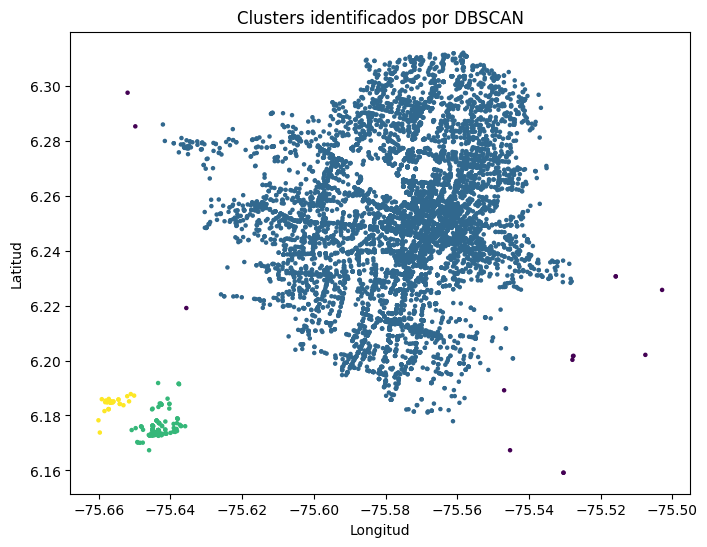

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    muestra_modelos["Longitud"],
    muestra_modelos["Latitud"],
    c=muestra_modelos["Cluster_DBSCAN"],
    s=5
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Clusters identificados por DBSCAN")

plt.show()

modelo 3: Clustering jerarquico

In [67]:
data_jerarquico = muestra_modelos[
    ["Latitud", "Longitud"]
].copy()

print(data_jerarquico.shape)

(10000, 2)


In [68]:
scaler_jerarquico = StandardScaler()

data_jerarquico_scaled = scaler_jerarquico.fit_transform(
    data_jerarquico
)

Aplicar el modelo jerárquico para diferentes números de clusters

In [69]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

resultados_jerarquico = []

for k in range(2, 7):

    modelo_jerarquico = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels_jerarquico = modelo_jerarquico.fit_predict(
        data_jerarquico_scaled
    )

    silueta_jerarquico = silhouette_score(
        data_jerarquico_scaled,
        labels_jerarquico
    )

    resultados_jerarquico.append({
        "Número de Clusters": k,
        "Coeficiente de Silueta": silueta_jerarquico
    })

resultados_jerarquico_df = pd.DataFrame(resultados_jerarquico)

resultados_jerarquico_df

,Número de Clusters,Coeficiente de Silueta
0,2,0.264834
1,3,0.318139
2,4,0.285491
3,5,0.292322
4,6,0.312408


El mejor resultado para el modelo jerárquico es:

3 clusters (Silueta: 0.3181)
Por lo tanto, para representar este modelo se utilizaran 3 clusters.

modelo jerarquico final

In [70]:
modelo_jerarquico_final = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels_jerarquico_final = modelo_jerarquico_final.fit_predict(
    data_jerarquico_scaled
)

Guardar el resultado

In [71]:
muestra_modelos["Cluster_Jerarquico"] = labels_jerarquico_final

Cual es la cantidad de accidentes en cada grupo?

In [72]:
muestra_modelos["Cluster_Jerarquico"].value_counts().sort_index()

,count
Cluster_Jerarquico,
0,4641
1,3804
2,1555


comparacion de los modelos:

| Modelo         | Clusters | Coeficiente de silueta | Resultado        |
| -------------- | -------: | ---------------------: | ---------------- |
| **K-Means**    |        2 |             **0.6898** | Mejor resultado  |
| **DBSCAN**     |        3 |             **0.6155** | Buen resultado   |
| **Jerárquico** |        3 |             **0.3181** | Menor separación |


Se selecciono K-Means como el modelo principal para el análisis espacial de los accidentes porque obtuvo el mayor coeficiente de silueta (0.6898), esto muestra que los grupos encontrados presentan una mejor separación entre sí en comparación con DBSCAN y el clustering jerárquico.
DBSCAN también presentó un buen resultado (0.6155) y permitió identificar tres zonas de concentración, pero para este análisis se utilizará K-Means como modelo principal porque tiene un mejor desempeño según el coeficiente de silueta.

In [74]:
data_kmeans = muestra_modelos[
    ["Latitud", "Longitud"]
].copy()

In [75]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_final.fit(data_kmeans)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [76]:
muestra_modelos["Cluster_KMeans"] = kmeans_final.labels_

In [77]:
muestra_modelos["Cluster_KMeans"].value_counts()

,count
Cluster_KMeans,
0,5001
1,4999


mapeo de clusters sobre mapa de medellin

In [78]:
import folium

In [79]:
mapa_medellin = folium.Map(
    location=[6.2442, -75.5812],
    zoom_start=12
)

In [80]:
muestra_mapa = muestra_modelos.sample(
    n=3000,
    random_state=42
)

In [81]:
colores = {
    0: "blue",
    1: "red"
}

for _, fila in muestra_mapa.iterrows():

    folium.CircleMarker(
        location=[
            fila["Latitud"],
            fila["Longitud"]
        ],
        radius=3,
        color=colores[fila["Cluster_KMeans"]],
        fill=True,
        fill_color=colores[fila["Cluster_KMeans"]],
        fill_opacity=0.6
    ).add_to(mapa_medellin)

In [82]:
mapa_medellin

In [83]:
centroides = kmeans_final.cluster_centers_

for i, centroide in enumerate(centroides):

    folium.Marker(
        location=[
            centroide[0],
            centroide[1]
        ],
        popup=f"Centroide Cluster {i}",
        icon=folium.Icon(
            color="green",
            icon="info-sign"
        )
    ).add_to(mapa_medellin)

In [84]:
mapa_medellin

In [85]:
# Lugares con mayor número de accidentes

ubicaciones_frecuentes = (
    datos_limpios
    .groupby(["Latitud", "Longitud"])
    .size()
    .reset_index(name="Numero_Accidentes")
    .sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

ubicaciones_frecuentes.head(10)

,Latitud,Longitud,Numero_Accidentes
25295,6.276299,-75.573364,722
24155,6.273389,-75.593021,676
14686,6.248048,-75.580468,633
14123,6.246884,-75.575211,629
21493,6.263846,-75.596633,629
25225,6.276171,-75.572869,608
25190,6.276081,-75.570616,560
13314,6.245048,-75.571505,496
23328,6.270420,-75.573845,486
4118,6.215066,-75.582006,478


direcciones de estas coordenadas

In [87]:
top_ubicaciones = ubicaciones_frecuentes.head(10)


In [88]:
top_accidentes = datos_limpios.merge(
    top_ubicaciones[["Latitud", "Longitud"]],
    on=["Latitud", "Longitud"],
    how="inner"
)

top_accidentes[
    [
        "Latitud",
        "Longitud",
        "DIRECCION",
        "nombre comuna",
        "Barrio",
        "Comuna"
    ]
].drop_duplicates().sort_values(
    ["Latitud", "Longitud"]
)

,Latitud,Longitud,DIRECCION,nombre comuna,Barrio,Comuna
6,6.215066,-75.582006,CR 52 CL 10,Guayabal,Campo Amor,15 - Guayabal
72,6.215066,-75.582006,CR 52 CL 11,Guayabal,Campo Amor,15 - Guayabal
304,6.215066,-75.582006,CR 53 CL 11 FF,Guayabal,Campo Amor,15 - Guayabal
484,6.215066,-75.582006,CR 53 BB CL 11 FF,Guayabal,Campo Amor,15 - Guayabal
662,6.215066,-75.582006,CR 52 CL 11 A,Guayabal,Campo Amor,15 - Guayabal
...,...,...,...,...,...,...
3209,6.276299,-75.573364,CR 65 B CL 81,Castilla,Terminal de Transporte,05 - Castilla
3837,6.276299,-75.573364,CR 64 C CL 81 A,Castilla,Terminal de Transporte,05 - Castilla
3987,6.276299,-75.573364,CR 65 DG 80,Castilla,Terminal de Transporte,05 - Castilla
4524,6.276299,-75.573364,CR 64 C Norte CL 80,Castilla,Terminal de Transporte,05 - Castilla


comunas con mayor accidentalidad

In [89]:
accidentes_comuna = (
    datos_limpios
    .groupby("nombre comuna")
    .size()
    .reset_index(name="Numero_Accidentes")
    .sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

accidentes_comuna.head(10)

,nombre comuna,Numero_Accidentes
13,La Candelaria,55372
14,Laureles Estadio,28774
3,Castilla,26405
10,El Poblado,23024
11,Guayabal,19597
1,Belén,17761
17,Robledo,17557
0,Aranjuez,15342
2,Buenos Aires,10376
12,La América,8552


ya tengo mas informacion para saber donde mandar los agentes de transito y las ambulancias

preparar variables de fecha y tiempo

In [90]:
datos_analisis = datos_limpios.copy()

datos_analisis["FECHA_ACCIDENTE"] = pd.to_datetime(
    datos_analisis["FECHA_ACCIDENTE"],
    errors="coerce"
)

datos_analisis["HORA"] = pd.to_datetime(
    datos_analisis["HORA_ACCIDENTE"].astype(str),
    errors="coerce"
).dt.hour

datos_analisis["MES"] = datos_analisis["FECHA_ACCIDENTE"].dt.month

datos_analisis["DIA_SEMANA"] = datos_analisis["FECHA_ACCIDENTE"].dt.day_name()

datos_analisis.head()

/tmp/ipykernel_2466/3799367496.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos_analisis["HORA"] = pd.to_datetime(


,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,CBML,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna,HORA,MES,DIA_SEMANA
0,1423828,6.219016,-75.602726,Choque,CR 80 CL 8,1611,Con heridos,Belén,Loma de los Bernal,Tramo de via,2014,2014-01-01,02:20:00,16,16 - Belén,2.0,1,Wednesday
1,1423839,6.260009,-75.568185,Atropello,CR 53 CL 61,1003,Con heridos,La Candelaria,Jesús Nazareno,Tramo de via,2014,2014-01-01,00:50:00,10,10 - La Candelaria,0.0,1,Wednesday
2,1423840,6.264765,-75.549943,Atropello,CR 39 CL 70,0308,Con heridos,Manrique,Manrique Oriental,Tramo de via,2014,2014-01-01,01:00:00,3,03 - Manrique,1.0,1,Wednesday
3,1423849,6.234327,-75.607611,Atropello,CL 32 CR 84,1617,Con heridos,Belén,Las Mercedes,Tramo de via,2014,2014-01-01,00:37:00,16,16 - Belén,0.0,1,Wednesday
4,1423890,6.300243,-75.579644,Caida Ocupante,CR 80 CL 101,0603,Con heridos,Doce De Octubre,Doce de Octubre No.2,Tramo de via,2014,2014-01-01,10:40:00,6,06 - Doce de Octubre,10.0,1,Wednesday


En que horas ocurren mas accidentes?

In [91]:
accidentes_hora = (
    datos_analisis
    .groupby("HORA")
    .size()
    .reset_index(name="Numero_Accidentes")
    .sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

accidentes_hora.head(10)

,HORA,Numero_Accidentes
17,17.0,17807
7,7.0,17051
12,12.0,16535
16,16.0,15976
6,6.0,15605
15,15.0,15272
13,13.0,15087
18,18.0,15002
14,14.0,14998
11,11.0,14742


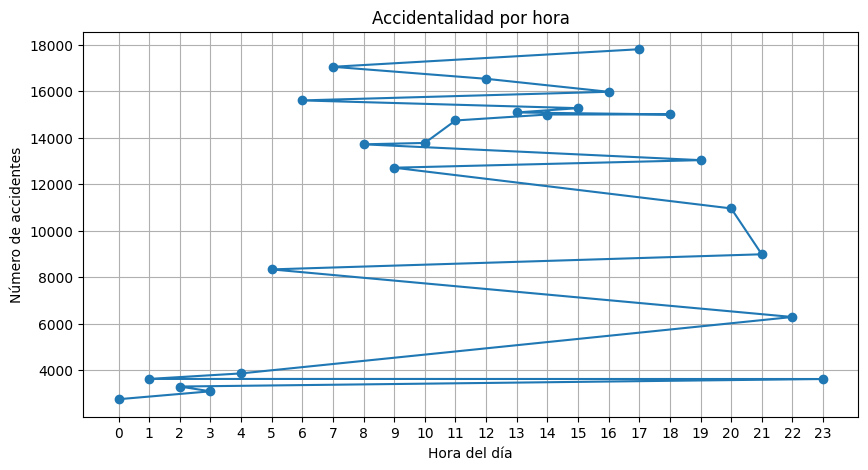

In [92]:
plt.figure(figsize=(10,5))

plt.plot(
    accidentes_hora["HORA"],
    accidentes_hora["Numero_Accidentes"],
    marker="o"
)

plt.xlabel("Hora del día")
plt.ylabel("Número de accidentes")

plt.title(
    "Accidentalidad por hora"
)

plt.xticks(range(0,24))

plt.grid()

plt.show()

que dias de la semana?

In [94]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

accidentes_dia = (
    datos_analisis
    .groupby("DIA_SEMANA")
    .size()
    .reindex(orden_dias)
    .reset_index(name="Numero_Accidentes")
)

accidentes_dia

,DIA_SEMANA,Numero_Accidentes
0,Monday,38195
1,Tuesday,41519
2,Wednesday,40518
3,Thursday,40050
4,Friday,42444
5,Saturday,38372
6,Sunday,25050


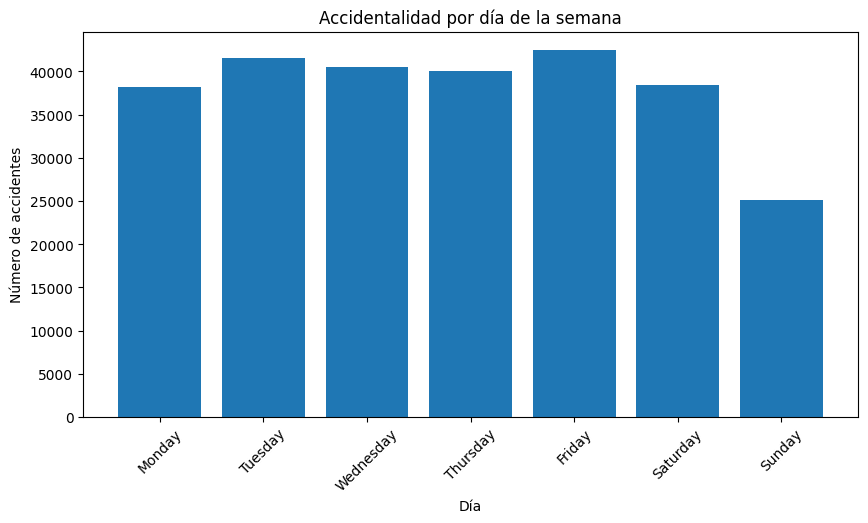

In [95]:
plt.figure(figsize=(10,5))

plt.bar(
    accidentes_dia["DIA_SEMANA"],
    accidentes_dia["Numero_Accidentes"]
)

plt.xlabel("Día")
plt.ylabel("Número de accidentes")

plt.title(
    "Accidentalidad por día de la semana"
)

plt.xticks(rotation=45)

plt.show()

accidentalidad de hora y dia

In [96]:
tabla_hora_dia = pd.crosstab(
    datos_analisis["DIA_SEMANA"],
    datos_analisis["HORA"]
)

tabla_hora_dia = tabla_hora_dia.reindex(orden_dias)

tabla_hora_dia

HORA,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
DIA_SEMANA,,,,,,,,,,,,,,,,,,,,,
Monday,387,526,502,441,557,1324,2429,2674,1952,1818,...,2013,2174,2403,2730,2372,1897,1530,1152,722,350
Tuesday,225,370,349,340,459,1373,2855,3026,2339,2091,...,2275,2322,2560,2990,2600,2059,1534,1274,761,363
Wednesday,234,390,345,322,468,1314,2751,2952,2297,2041,...,2275,2312,2420,2881,2394,1973,1619,1258,769,403
Thursday,284,395,366,351,431,1303,2701,2913,2206,2065,...,2204,2255,2370,2956,2310,2039,1569,1337,865,407
Friday,315,460,379,394,525,1325,2637,2937,2232,1978,...,2336,2410,2739,3058,2415,2104,1761,1472,1054,679
Saturday,540,656,587,567,638,954,1413,1742,1816,1761,...,2438,2409,2141,1995,1740,1738,1710,1453,1316,902
Sunday,768,829,771,678,785,744,819,807,875,957,...,1457,1390,1343,1197,1171,1226,1237,1041,803,518


para esto voy a hacer un mapa de calor

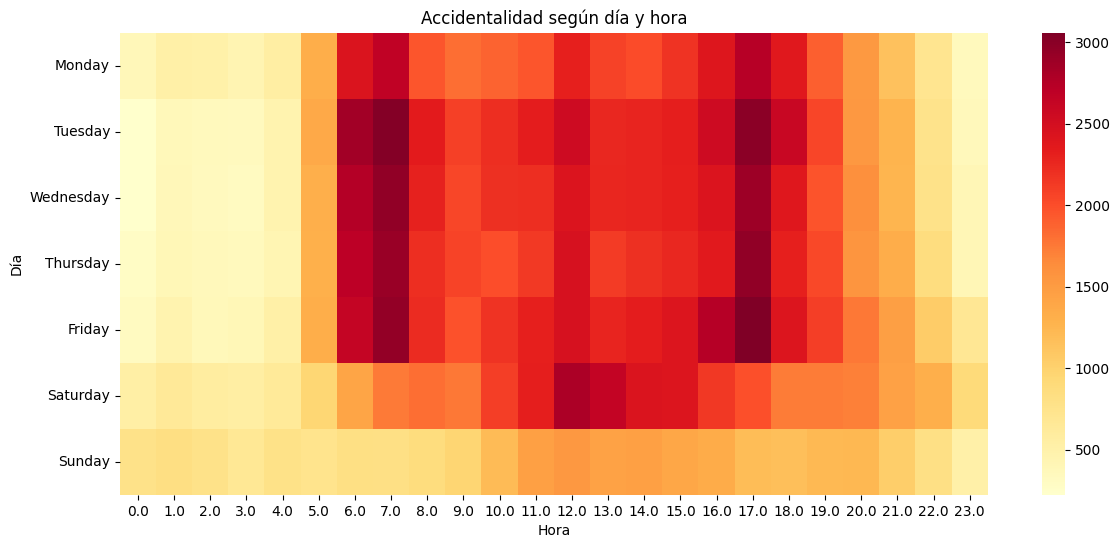

In [97]:
plt.figure(figsize=(14,6))

sns.heatmap(
    tabla_hora_dia,
    cmap="YlOrRd"
)

plt.title(
    "Accidentalidad según día y hora"
)

plt.xlabel("Hora")

plt.ylabel("Día")

plt.show()

tipos de accidentes mas frecuentes

In [98]:
tipos_accidente = (
    datos_analisis
    .groupby("CLASE_ACCIDENTE")
    .size()
    .reset_index(name="Numero_Accidentes")
    .sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

tipos_accidente

,CLASE_ACCIDENTE,Numero_Accidentes
2,Choque,179794
5,Otro,28335
0,Atropello,25606
1,Caida Ocupante,23269
6,Volcamiento,9102
4,Incendio,32
3,Choque,3


y cuales son los mas graves para decidir donde ubicar las ambulancias

In [99]:
gravedad = (
    datos_analisis
    .groupby("Gravedad Incidente")
    .size()
    .reset_index(name="Numero_Accidentes")
    .sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

gravedad

,Gravedad Incidente,Numero_Accidentes
1,Con heridos,145227
3,Solo daños,119475
2,Con muertos,1419
0,Con Muertos,27


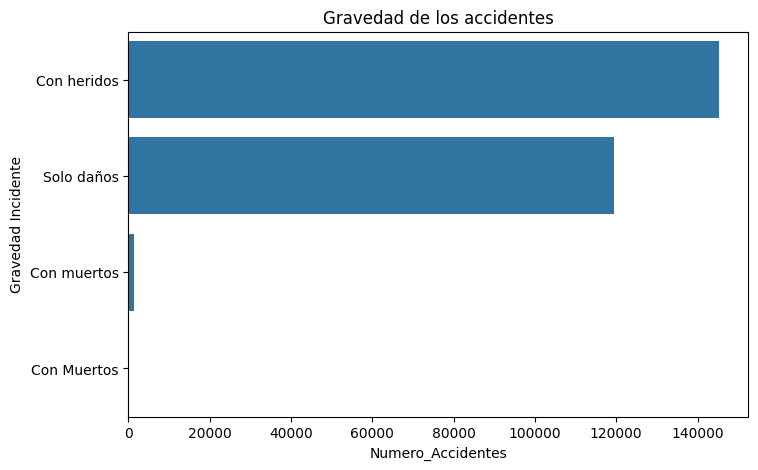

In [100]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=gravedad,
    x="Numero_Accidentes",
    y="Gravedad Incidente"
)

plt.title(
    "Gravedad de los accidentes"
)

plt.show()

Como cambia la accidentalidad por año?

In [102]:
accidentes_ano = (
    datos_analisis
    .groupby("Año")
    .size()
    .reset_index(name="Numero_Accidentes")
)

accidentes_ano

,Año,Numero_Accidentes
0,2014,42063
1,2015,42642
2,2016,43493
3,2017,42652
4,2018,39748
5,2019,42467
6,2020,13083


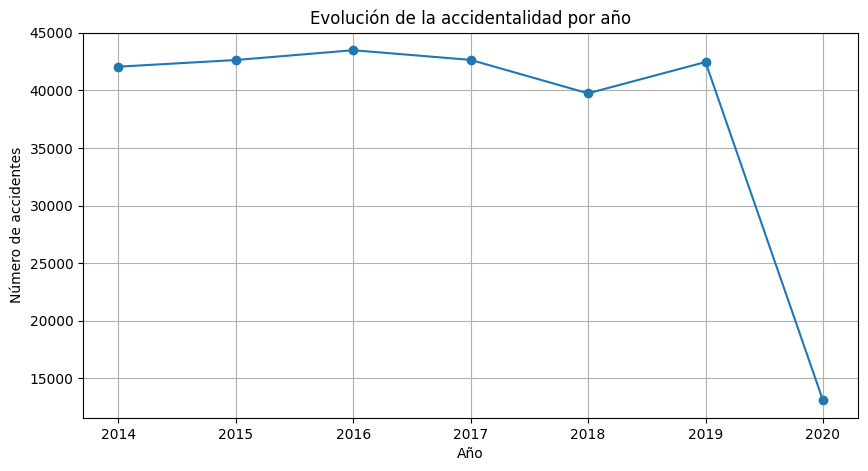

In [103]:
plt.figure(figsize=(10,5))

plt.plot(
    accidentes_ano["Año"],
    accidentes_ano["Numero_Accidentes"],
    marker="o"
)

plt.xlabel("Año")

plt.ylabel("Número de accidentes")

plt.title(
    "Evolución de la accidentalidad por año"
)

plt.grid()

plt.show()

que meses son mas peligrosos?

In [104]:
accidentes_mes = (
    datos_analisis
    .groupby("MES")
    .size()
    .reset_index(name="Numero_Accidentes")
)

accidentes_mes

,MES,Numero_Accidentes
0,1,21561
1,2,23537
2,3,23540
3,4,21230
4,5,23201
5,6,21998
6,7,21734
7,8,22708
8,9,22191
9,10,22236


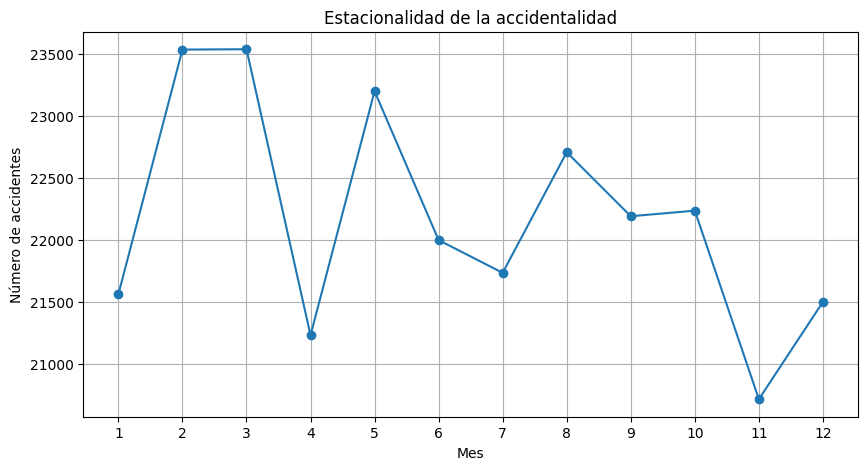

In [105]:
plt.figure(figsize=(10,5))

plt.plot(
    accidentes_mes["MES"],
    accidentes_mes["Numero_Accidentes"],
    marker="o"
)

plt.xticks(range(1,13))

plt.xlabel("Mes")

plt.ylabel("Número de accidentes")

plt.title(
    "Estacionalidad de la accidentalidad"
)

plt.grid()

plt.show()

que fechas especificas tienen mas accidentes?

In [106]:
fechas_criticas = (
    datos_analisis
    .groupby("FECHA_ACCIDENTE")
    .size()
    .reset_index(name="Numero_Accidentes")
    .sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

fechas_criticas.head(15)

,FECHA_ACCIDENTE,Numero_Accidentes
1311,2017-08-04,217
2053,2019-08-16,210
2074,2019-09-06,204
828,2016-04-08,188
2141,2019-11-12,188
2164,2019-12-05,186
594,2015-08-18,185
1010,2016-10-07,183
604,2015-08-28,182
2039,2019-08-02,179


resumen final

In [107]:
print("========== HORAS CON MAYOR ACCIDENTALIDAD ==========")
print(accidentes_hora.head(5))

print("\n========== DÍAS CON MAYOR ACCIDENTALIDAD ==========")
print(
    accidentes_dia.sort_values(
        by="Numero_Accidentes",
        ascending=False
    ).head(5)
)

print("\n========== TIPOS DE ACCIDENTE MÁS FRECUENTES ==========")
print(tipos_accidente.head())

print("\n========== GRAVEDAD DE LOS ACCIDENTES ==========")
print(gravedad)

print("\n========== AÑOS ==========")
print(
    accidentes_ano.sort_values(
        by="Numero_Accidentes",
        ascending=False
    )
)

print("\n========== MESES MÁS CRÍTICOS ==========")
print(
    accidentes_mes.sort_values(
        by="Numero_Accidentes",
        ascending=False
    ).head(5)
)

print("\n========== FECHAS MÁS CRÍTICAS ==========")
print(fechas_criticas.head(10))

========== HORAS CON MAYOR ACCIDENTALIDAD ==========
    HORA  Numero_Accidentes
17  17.0              17807
7    7.0              17051
12  12.0              16535
16  16.0              15976
6    6.0              15605

========== DÍAS CON MAYOR ACCIDENTALIDAD ==========
  DIA_SEMANA  Numero_Accidentes
4     Friday              42444
1    Tuesday              41519
2  Wednesday              40518
3   Thursday              40050
5   Saturday              38372

========== TIPOS DE ACCIDENTE MÁS FRECUENTES ==========
  CLASE_ACCIDENTE  Numero_Accidentes
2          Choque             179794
5            Otro              28335
0       Atropello              25606
1  Caida Ocupante              23269
6     Volcamiento               9102

========== GRAVEDAD DE LOS ACCIDENTES ==========
  Gravedad Incidente  Numero_Accidentes
1        Con heridos             145227
3         Solo daños             119475
2        Con muertos               1419
0        Con Muertos                 27

====

**Analisis final y recomendaciones**

1. ¿Dónde ubicar los agentes de tránsito y las ambulancias?

### Agentes de tránsito

Se recomienda priorizar las comunas con mayor accidentalidad:

* **La Candelaria:** 55.372 accidentes.
* **Laureles Estadio:** 28.774.
* **Castilla:** 26.405.
* **El Poblado:** 23.024.
* **Guayabal:** 19.597.


Se identificaron puntos críticos específicos en Castilla, barrio Terminal de Transporte, en direcciones cercanas a CR 65 B CL 81 y CR 64 C CL 80–81;

y en Guayabal, en el barrio Campo Amor, en el sector de CR 52 CL 10 y CR 52 CL 11.

Por lo tanto, los agentes deberían distribuirse tanto en las comunas con mayor accidentalidad como en estos puntos de alta concentración.

### Ambulancias

Las ambulancias deberían ubicarse estratégicamente cerca de los sectores con mayor concentración de accidentes, especialmente **La Candelaria, Castilla y Guayabal**

Esto es importante porque la mayoría de los accidentes fueron **con heridos (145.227 casos)**.


## 2. ¿Qué horarios y personal debe estar disponible?

Las horas con mayor accidentalidad fueron:

* **5:00 p.m.: 17.807 accidentes.**
* **7:00 a.m.: 17.051.**
* **12:00 p.m.: 16.535.**
* **4:00 p.m.: 15.976.**
* **6:00 a.m.: 15.605.**

Por lo tanto, se recomienda reforzar agentes y ambulancias principalmente:

* **6:00 a.m. – 8:00 a.m.**
* **11:00 a.m. – 1:00 p.m.**
* **4:00 p.m. – 6:00 p.m.**

El día con mayor accidentalidad fue el **viernes, con 42.444 accidentes**, seguido por el martes y el miércoles. Por esto, los viernes debería haber una mayor disponibilidad de personal.

El tipo de accidente más frecuente son los **choques**, con 17.794 casos.

## 3. ¿Qué muestran los años y la estacionalidad?

Entre **2014 y 2019**, la accidentalidad se mantuvo alta, alrededor de los 40.000 accidentes anuales. El año con mayor accidentalidad fue **2016, con 43.493 accidentes**.

Los meses más críticos fueron:

* **Marzo: 23.540 accidentes.**
* **Febrero: 23.537.**
* **Mayo: 23.201.**

Por lo tanto, durante estos meses se recomienda aumentar la disponibilidad de agentes, ambulancias y campañas de prevención.


## 4. Recomendaciones para prevenir accidentes

1. **Aumentar la presencia de agentes** en La Candelaria, Castilla, Laureles Estadio, El Poblado y Guayabal.
2. **Priorizar los puntos críticos** identificados en Campo Amor y Terminal de Transporte.
3. **Reforzar el personal** entre las 6:00–8:00 a.m.,

 11:00 a.m.–1:00 p.m.

 y 4:00–6:00 p.m.

4. Implementar medidas para reducir los **choques**, que son el tipo de accidente más frecuente.

5. Reforzar las medidas preventivas durante **febrero, marzo y mayo**, los meses con mayor accidentalidad.

### Conclusión

Los resultados permiten concluir que los recursos deben distribuirse según la ubicación, el horario y la estacionalidad de los accidentes. La prioridad debe centrarse en las comunas y puntos críticos mostrados anteriormente, especialmente durante las horas pico y los viernes, reforzando la capacidad de prevención y respuesta ante los accidentes con heridos.
